In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/updated_data.csv")

excluded_cols = ['prov_name', 'fem_empl_rate', 'urban_type', 'empl_gap', 'private_coverage']
df = df.drop(columns=excluded_cols)
df["ecec_diffusion"] = df["ecec_diffusion"].fillna(df["ecec_diffusion"].median())

In [3]:
corr_matrix = df.corr()

# avoid duplicate pairs and self-correlation
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.89

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
)

high_corr_pairs = (
    high_corr_pairs[high_corr_pairs['corr'].abs() >= threshold]
    .sort_values(by='corr', key=np.abs, ascending=False)
)

In [4]:
print("Highly correlated pairs")
print(high_corr_pairs.to_string(index=False, float_format=lambda x: f"{x: .3f}"))

Highly correlated pairs
                              var1                         var2   corr
other_percapita_public_expenditure other_per_capita_expenditure  0.995
                         empl_rate                   inact_rate -0.989
                net_migration_rate       adj_net_migration_rate  0.985
                         part_rate                   inact_rate -0.978
                         part_rate                    empl_rate  0.973
                         empl_rate                       wr_men  0.968
                      fem_edu_rate                male_edu_rate  0.952
                        inact_rate                       wr_men -0.950
                         part_rate                       wr_men  0.940
                       unempl_rate                    empl_rate -0.918
                       unempl_rate                       wr_men -0.916
                         empl_rate                   young_neet -0.900


In [5]:
var_counts = (
    pd.concat([high_corr_pairs["var1"], high_corr_pairs["var2"]])
      .value_counts()
)

var_presence_list = list(var_counts.items())

for var, count in var_presence_list:
    print(f"({var}, {count})")

(empl_rate, 5)
(wr_men, 4)
(inact_rate, 3)
(part_rate, 3)
(unempl_rate, 2)
(other_percapita_public_expenditure, 1)
(net_migration_rate, 1)
(fem_edu_rate, 1)
(other_per_capita_expenditure, 1)
(adj_net_migration_rate, 1)
(male_edu_rate, 1)
(young_neet, 1)


In [6]:
# we will talk about which one actually to drop

var_to_drop = ['empl_rate', 'inact_rate', 'male_edu_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate']

df_reduced = df.drop(columns=var_to_drop)

offset = df_reduced['wr_men']
offset = offset.to_numpy()
offset = offset / 100 
logit_offset = np.log(offset / (1 - offset))

# Other variables to consider dropping based on domain knowledge
to_drop = ['part_rate', 'unempl_rate', 'wr_men']

df_reduced = df_reduced.drop(columns=to_drop)

In [7]:
# print(df_reduced.shape)
# logit_offset.shape

In [8]:
selected_covariates = list(df_reduced.columns)

df_full = pd.read_csv("../data/updated_data.csv")
target_col = "fem_empl_rate"

df_model = df_full[[target_col] + selected_covariates]

print("Selected covariates used in the model:")
print(selected_covariates)


X = df_reduced.to_numpy()
y = df_model[target_col].to_numpy()


# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std()
y = y / 100
y_scaled = np.log(y / (1 - y))

n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


Selected covariates used in the model:
['population', 'empl_growth', 'fem_edu_rate', 'service_empl_rate', 'GDP', 'n_large_comp', 'n_self_empl', 'young_neet', 'fem_house_rate', 'foreign_rate', 'n_members_family', 'elderly_in_care', 'house_price', 'fertility_rate', 'first_birth_maternal_age', 'avg_children_per_woman', 'dependency_rate', 'ageing_index', 'net_migration_rate', 'area_km2', 'public_transport_supply', 'internet_coverage_rate', 'graduate_mobility_rate', 'green_m2_capita', 'eco_urban_index', 'per_capita_public_expenditure', 'ecec_participation', 'coverage', 'per_capita_user_contribution', 'advanced_business_empl', 'lifelong_learn', 'startup_ratio', 'GERD_total_intramural', 'public_coverage', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'fem_maj_empl_rate', 'ecec_diffusion']

Number of observations: 107, number of predictors: 38


(array([ 1.,  0.,  0.,  2.,  2.,  2.,  3.,  1.,  2.,  3.,  4.,  1.,  3.,
         2.,  2.,  2.,  4.,  5.,  2.,  6.,  4.,  5., 11.,  8., 11.,  7.,
        10.,  1.,  2.,  1.]),
 array([-0.10815426, -0.05803534, -0.00791642,  0.0422025 ,  0.09232142,
         0.14244034,  0.19255926,  0.24267818,  0.2927971 ,  0.34291603,
         0.39303495,  0.44315387,  0.49327279,  0.54339171,  0.59351063,
         0.64362955,  0.69374847,  0.74386739,  0.79398631,  0.84410523,
         0.89422416,  0.94434308,  0.994462  ,  1.04458092,  1.09469984,
         1.14481876,  1.19493768,  1.2450566 ,  1.29517552,  1.34529444,
         1.39541337]),
 <BarContainer object of 30 artists>)

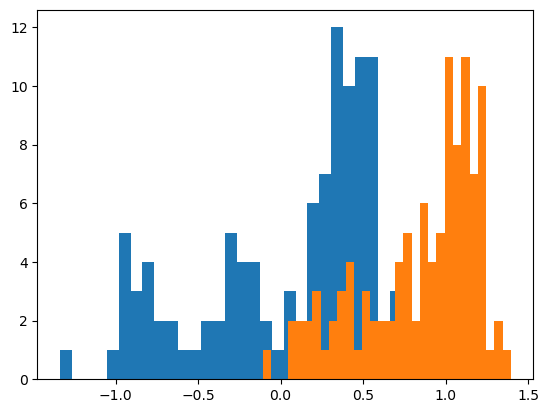

In [9]:
plt.hist(y_scaled, bins=30)
plt.hist(logit_offset, bins=30)

(array([ 1.,  0.,  0.,  0.,  1.,  5.,  3.,  4.,  2.,  2.,  1.,  1.,  2.,
         2.,  5.,  4.,  4.,  2.,  1.,  3.,  1.,  6.,  7., 12., 10., 11.,
        11.,  1.,  3.,  2.]),
 array([-1.33702331, -1.26562925, -1.19423519, -1.12284113, -1.05144706,
        -0.980053  , -0.90865894, -0.83726488, -0.76587082, -0.69447675,
        -0.62308269, -0.55168863, -0.48029457, -0.40890051, -0.33750644,
        -0.26611238, -0.19471832, -0.12332426, -0.0519302 ,  0.01946387,
         0.09085793,  0.16225199,  0.23364605,  0.30504011,  0.37643418,
         0.44782824,  0.5192223 ,  0.59061636,  0.66201042,  0.73340448,
         0.80479855]),
 <BarContainer object of 30 artists>)

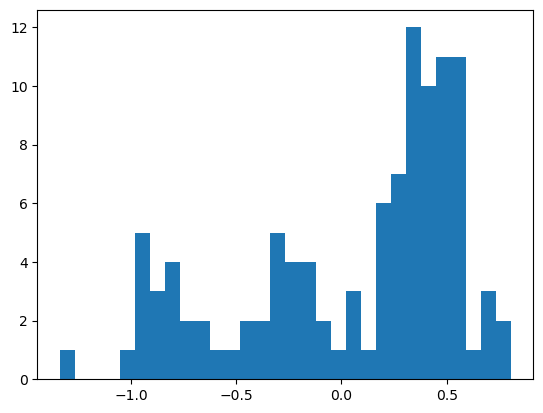

In [ ]:
plt.hist(y_scaled, bins=30)
plt.hist(y, bins=30)

In [11]:
print("X_data shape:", X_scaled.shape)
print("y_data shape:", y_scaled.shape)

X_data shape: (107, 38)
y_data shape: (107,)


In [ ]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    # lambda_ = pm.Gamma("lambda", alpha=2.0, beta=1.0)
    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)  # shape/rate
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    # offset_values = pm.Data("offset", logit_offset)
    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
    mu = pm.math.dot(X_data, beta) + intercept

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that

In [ ]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    # lambda_ = pm.Gamma("lambda", alpha=2.0, beta=1.0)
    lambda_sq = pm.Gamma("lambda_sq", alpha=2.0, beta=1.0)  # shape/rate
    lambda_ = pm.Deterministic("lambda", pm.math.sqrt(lambda_sq))

    sigma = pm.HalfNormal("sigma", sigma=1.0)

    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    offset_values = pm.Data("offset", logit_offset)
    intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
    mu = pm.math.dot(X_data, beta) + intercept + offset_values

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

c:\Users\leona\miniconda3\envs\bayesian\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_sq, sigma, beta, alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 23 seconds.


In [ ]:
# with pm.Model() as hs_model:
#     X_data = pm.Data("X_data", X_scaled)
#     y_data = pm.Data("y_data", y_scaled)

#     lambda_ = pm.HalfCauchy("lambda", beta=1.0, shape=n_feat)
#     sigma = pm.HalfCauchy("sigma", beta=1.0)
#     tau = pm.HalfCauchy("tau", beta=1.0)

#     # beta = pm.Normal("beta", mu=0, sigma=lambda_*tau, shape=n_feat)
#     z = pm.Normal("z", mu=0.0, sigma=1.0, shape=n_feat)
#     beta = pm.Deterministic("beta", z * lambda_ * tau)

#     intercept = pm.Normal("alpha", mu=0.0, sigma=10.0)
#     mu = pm.math.dot(X_data, beta) + intercept

#     y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

#     trace = pm.sample(
#         draws=2000,
#         tune=2000,
#         target_accept=0.9,
#         return_inferencedata=True,
#         random_seed=42
#     )

In [ ]:
summary_beta_95 = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta_95.index = selected_covariates

summary_beta_95["contains_zero"] = (
    (summary_beta_95["hdi_2.5%"] <= 0) &
    (summary_beta_95["hdi_97.5%"] >= 0)
)

summary_beta_95 = summary_beta_95.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_95[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])

                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.297    -0.379     -0.216          False
net_migration_rate                 -0.076    -0.141     -0.004          False
ageing_index                        0.068    -0.016      0.163           True
avg_children_per_woman             -0.065    -0.123     -0.006          False
n_members_family                   -0.061    -0.117     -0.001          False
fertility_rate                     -0.036    -0.116      0.035           True
GDP                                -0.032    -0.105      0.027           True
dependency_rate                    -0.031    -0.095      0.026           True
fem_maj_empl_rate                   0.030    -0.002      0.060           True
ecec_participation                  0.027    -0.025      0.089           True
ecec_diffusion                     -0.026    -0.061      0.005           True
fem_edu_rate                       -0.025    -0.066      0.013  

In [ ]:
summary_beta_80 = az.summary(trace, var_names=["beta"], hdi_prob=0.80)

summary_beta_80.index = selected_covariates

summary_beta_80["contains_zero"] = (
    (summary_beta_80["hdi_10%"] <= 0) &
    (summary_beta_80["hdi_90%"] >= 0)
)

summary_beta_80 = summary_beta_80.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta_80[["mean", "hdi_10%", "hdi_90%", "contains_zero"]])

                                     mean  hdi_10%  hdi_90%  contains_zero
fem_house_rate                     -0.297   -0.350   -0.243          False
net_migration_rate                 -0.076   -0.123   -0.033          False
ageing_index                        0.068    0.000    0.120           True
avg_children_per_woman             -0.065   -0.104   -0.025          False
n_members_family                   -0.061   -0.097   -0.020          False
fertility_rate                     -0.036   -0.083    0.015           True
GDP                                -0.032   -0.073    0.012           True
dependency_rate                    -0.031   -0.067    0.010           True
fem_maj_empl_rate                   0.030    0.008    0.049          False
ecec_participation                  0.027   -0.011    0.061           True
ecec_diffusion                     -0.026   -0.047   -0.004          False
fem_edu_rate                       -0.025   -0.049    0.003           True
coverage                 

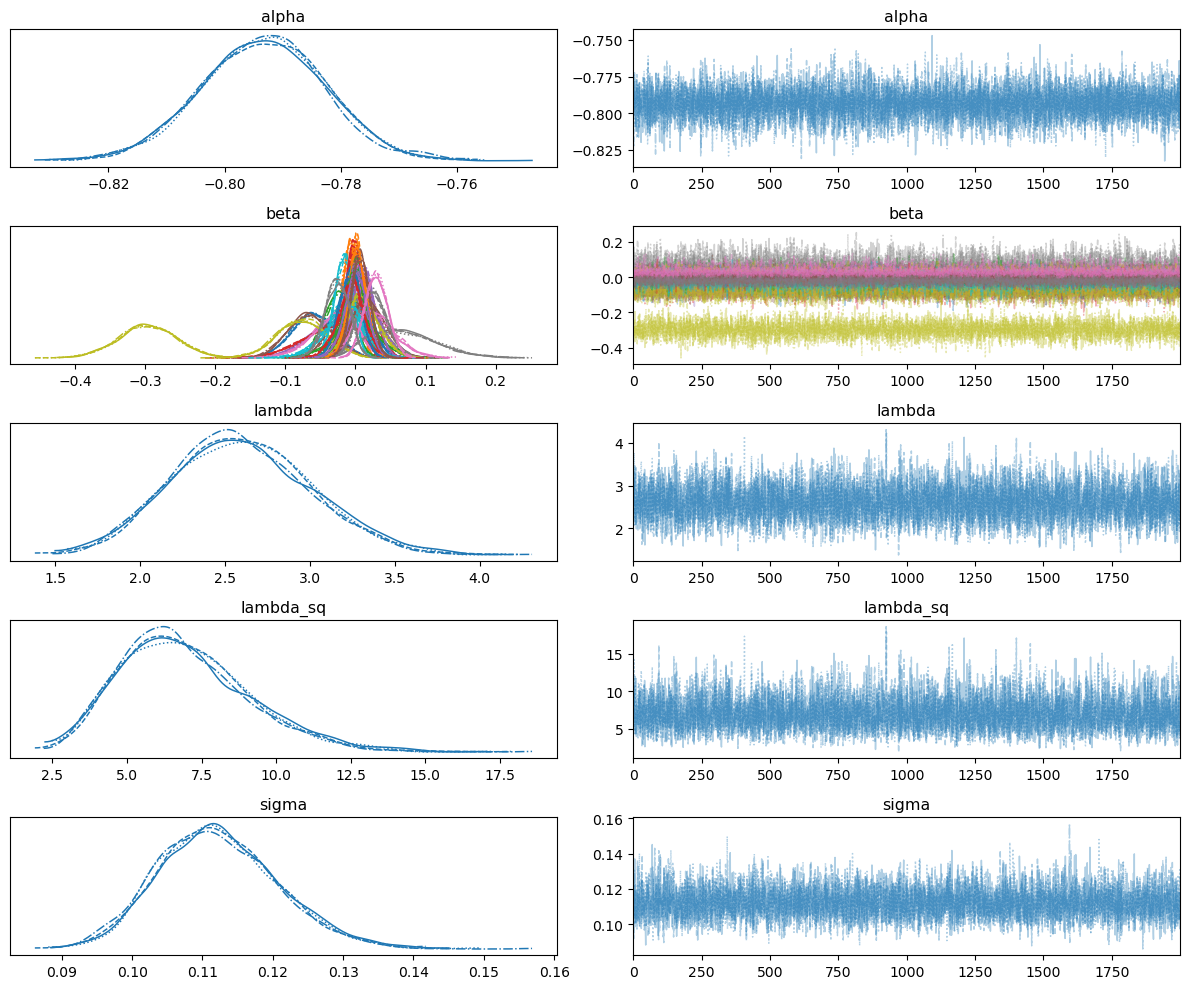

In [ ]:
# az.rcParams["plot.max_subplots"] = 100   
# az.plot_trace(trace, compact=False)

az.plot_trace(trace)
plt.tight_layout()

C:\Users\leona\AppData\Local\Temp\ipykernel_23888\1335099598.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


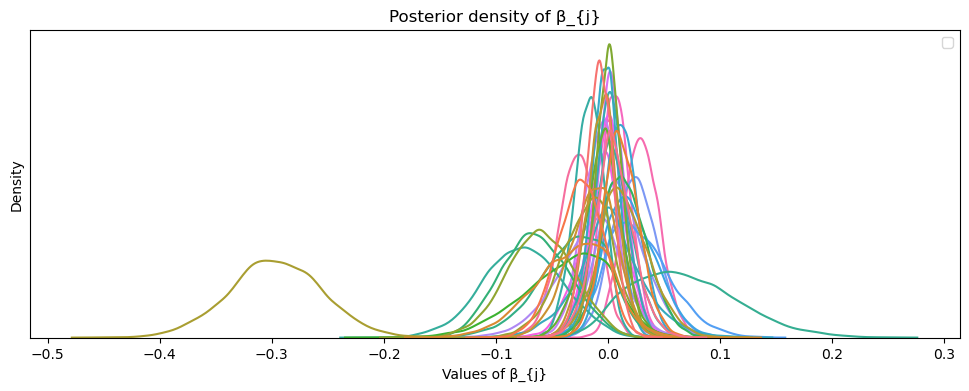

In [ ]:
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))
sns.kdeplot(beta_samples.T, legend=False)

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()

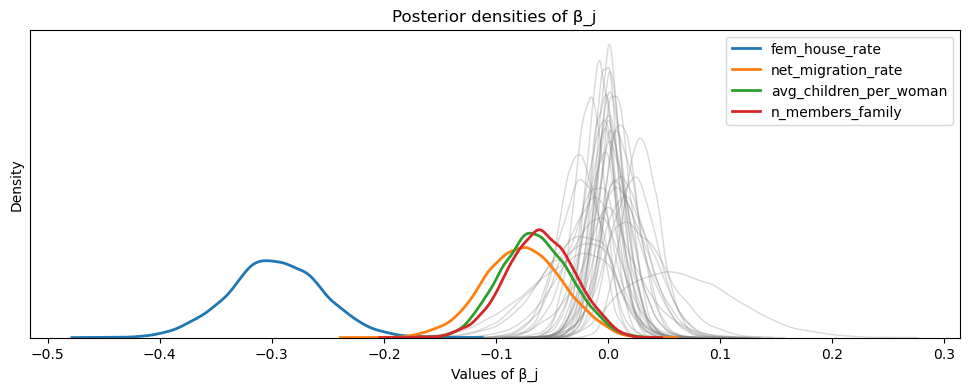

In [ ]:
# 1. Get beta samples in shape: (n_feat, n_samples)
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  # (n_samples, n_feat) typically
if beta_raw.shape[0] == len(selected_covariates):
    # then it's (n_feat, n_samples) already
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  # (n_feat, n_samples)

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

# 2. Plot all betas in gray (background)
for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

# 3. Overlay and label only those whose HDI does NOT contain zero
for name in summary_beta_95.index[~summary_beta_95["contains_zero"]]:
    # map variable name -> correct column index in beta_samples
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()


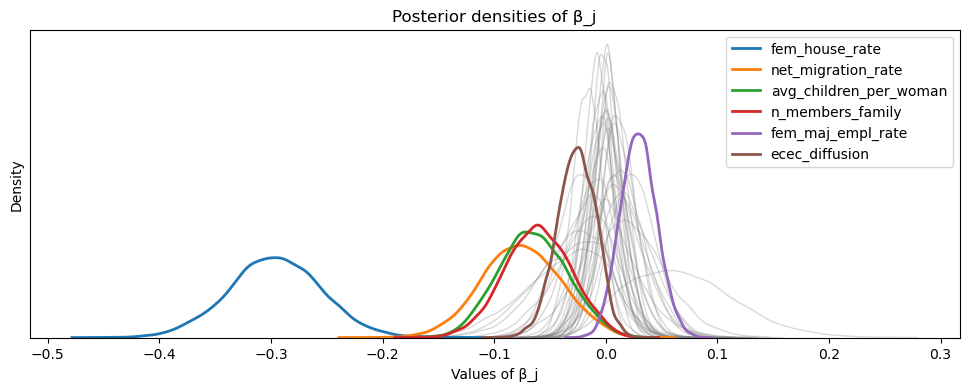

In [ ]:
# 1. Get beta samples in shape: (n_feat, n_samples)
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  # (n_samples, n_feat) typically
if beta_raw.shape[0] == len(selected_covariates):
    # then it's (n_feat, n_samples) already
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  # (n_feat, n_samples)

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

# 2. Plot all betas in gray (background)
for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

# 3. Overlay and label only those whose HDI does NOT contain zero
for name in summary_beta_80.index[~summary_beta_80["contains_zero"]]:
    # map variable name -> correct column index in beta_samples
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

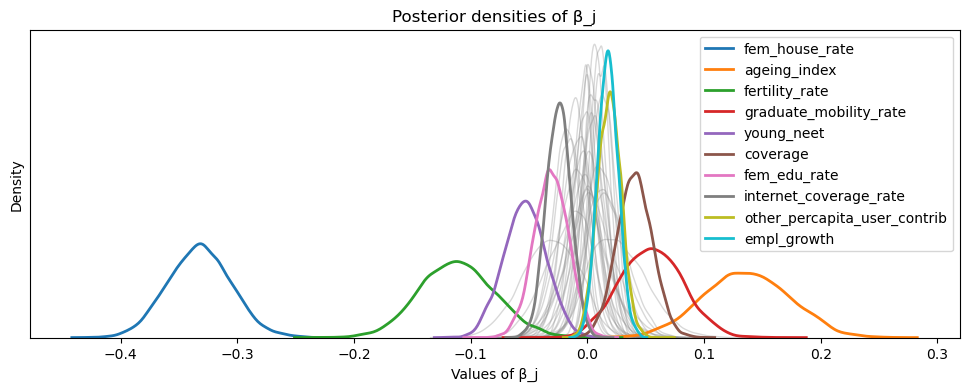

In [ ]:
# 1. Get beta samples in shape: (n_feat, n_samples)
beta_raw = trace.posterior["beta"].stack(samples=("chain", "draw")).values  # (n_samples, n_feat) typically
if beta_raw.shape[0] == len(selected_covariates):
    # then it's (n_feat, n_samples) already
    beta_samples = beta_raw
else:
    beta_samples = beta_raw.T  # (n_feat, n_samples)

n_feat = len(selected_covariates)

plt.figure(figsize=(12, 4))

# 2. Plot all betas in gray (background)
for j in range(n_feat):
    sns.kdeplot(beta_samples[j, :], color="gray", alpha=0.3, linewidth=1)

# 3. Overlay and label only those whose HDI does NOT contain zero
for name in summary_beta_90.index[~summary_beta_90["contains_zero"]]:
    # map variable name -> correct column index in beta_samples
    j = selected_covariates.index(name)
    sns.kdeplot(beta_samples[j, :], linewidth=2, label=name)

plt.legend()
plt.title("Posterior densities of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()

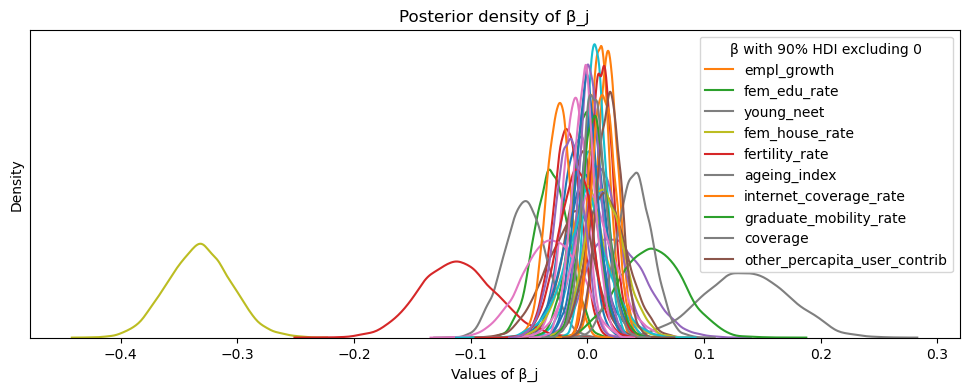

In [ ]:
# Rebuild beta_samples in "features x samples" shape
beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values  # (samples, n_feat) or (n_feat, samples)
if beta_samples.shape[0] != len(selected_covariates):
    beta_samples = beta_samples.T  # make it (n_feat, samples)

plt.figure(figsize=(12, 4))

for j, name in enumerate(selected_covariates):
    # Is zero inside the 90% HDI?
    contains_zero = summary_beta_90.loc[name, "contains_zero"]

    # Only give a label if HDI *does not* contain zero
    label = None if contains_zero else name

    sns.kdeplot(beta_samples[j, :], label=label)

plt.legend(title="β with 90% HDI excluding 0")
plt.title("Posterior density of β_j")
plt.xlabel("Values of β_j")
plt.yticks([])
plt.gca().tick_params(axis='y', length=0)
plt.show()


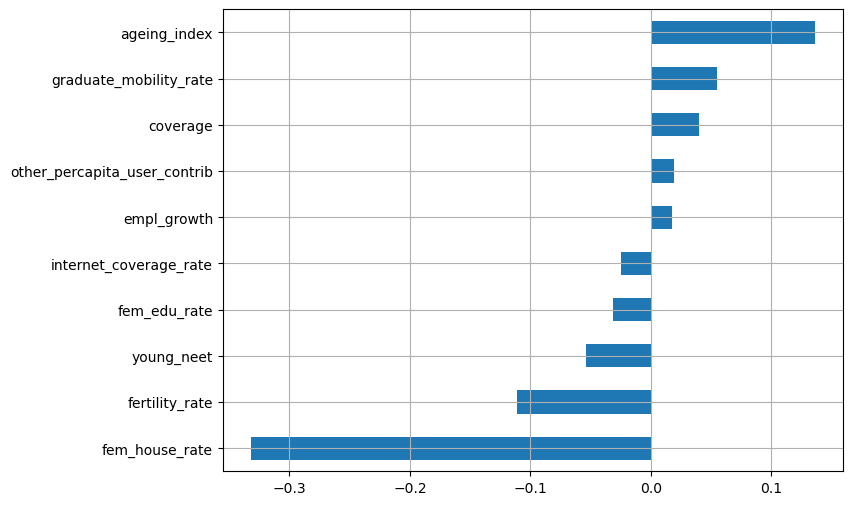

In [ ]:
plt.figure(figsize=(8,6))
summary_beta_90 = summary_beta_90[summary_beta_90["contains_zero"] == False]['mean']
summary_beta_90.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()